In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

# Initial version of the Logistic Regression baseline. The final version is in the final_files folder.

In [3]:
df = pd.read_csv("big_startup_secsees_dataset.csv")
print(df.shape)
df.head()

(66368, 14)


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


In [4]:
# we keep the rows where the outcome is known and unambiguous

good_status = ["closed", "acquired", "ipo"]
data = df[df["status"].isin(good_status)].copy()

data["target"] = 0
data.loc[data["status"].isin(["acquired", "ipo"]), "target"] = 1

print("labelled shape:", data.shape)
print(data["target"].value_counts())

labelled shape: (13334, 15)
target
1    7096
0    6238
Name: count, dtype: int64


In [5]:
# checking for duplicates

print("duplicate rows:", data.duplicated().sum())
print("duplicate permalinks:", data["permalink"].duplicated().sum())

name_check = data["name"].fillna("").str.lower().str.strip()
home_check = data["homepage_url"].fillna("").str.lower().str.strip()

print("duplicate names:", name_check[name_check != ""].duplicated().sum())
print("duplicate homepages:", home_check[home_check != ""].duplicated().sum())

duplicate rows: 0
duplicate permalinks: 0
duplicate names: 11
duplicate homepages: 17


In [6]:
# these are identifiers or text columns we have chosen not to use as model features

data = data.drop(columns=["permalink", "name", "homepage_url"]).copy()

In [7]:
# funding

data["funding_num"] = data["funding_total_usd"].replace("-", np.nan)
data["funding_num"] = pd.to_numeric(data["funding_num"], errors="coerce")

data["funding_missing"] = data["funding_num"].isna().astype(int)
data["log_funding"] = np.log1p(data["funding_num"])

data["funding_rounds"] = pd.to_numeric(data["funding_rounds"], errors="coerce")

In [8]:
# dates

data["founded_at"] = pd.to_datetime(data["founded_at"], errors="coerce")
data["first_funding_at"] = pd.to_datetime(data["first_funding_at"], errors="coerce")
data["last_funding_at"] = pd.to_datetime(data["last_funding_at"], errors="coerce")

# a few dates are clearly broken, so we set those to missing
for col in ["founded_at", "first_funding_at", "last_funding_at"]:
    bad_date = (data[col].dt.year < 1900) | (data[col].dt.year > 2016)
    data.loc[bad_date, col] = pd.NaT

data["founded_missing"] = data["founded_at"].isna().astype(int)
data["first_funding_missing"] = data["first_funding_at"].isna().astype(int)
data["last_funding_missing"] = data["last_funding_at"].isna().astype(int)

data["founded_year"] = data["founded_at"].dt.year
data["first_year"] = data["first_funding_at"].dt.year
data["last_year"] = data["last_funding_at"].dt.year

data["first_gap"] = (data["first_funding_at"] - data["founded_at"]).dt.days
data["funding_days"] = (data["last_funding_at"] - data["first_funding_at"]).dt.days
data["startup_days"] = (data["last_funding_at"] - data["founded_at"]).dt.days

data["bad_first_gap"] = (data["first_gap"] < 0).fillna(False).astype(int)
data.loc[data["first_gap"] < 0, "first_gap"] = np.nan

data["bad_funding_days"] = (data["funding_days"] < 0).fillna(False).astype(int)
data.loc[data["funding_days"] < 0, "funding_days"] = np.nan

data["bad_startup_days"] = (data["startup_days"] < 0).fillna(False).astype(int)
data.loc[data["startup_days"] < 0, "startup_days"] = np.nan

In [9]:
# categories

data["main_cat"] = data["category_list"].fillna("MISSING").str.split("|").str[0]
data["n_cat"] = data["category_list"].fillna("").str.count(r"\|") + data["category_list"].notna().astype(int)

data["country_small"] = data["country_code"].fillna("MISSING")
country_counts = data["country_small"].value_counts()
keep_country = country_counts[country_counts >= 30].index
data.loc[~data["country_small"].isin(keep_country), "country_small"] = "OTHER"

data["main_cat_small"] = data["main_cat"].fillna("MISSING")
cat_counts = data["main_cat_small"].value_counts()
keep_cat = cat_counts[cat_counts >= 50].index
data.loc[~data["main_cat_small"].isin(keep_cat), "main_cat_small"] = "OTHER"

In [10]:
# Spearman check for the numeric columns which will be used before choosing the final columns

corr_cols = [
    "funding_rounds",
    "log_funding",
    "founded_year",
    "first_year",
    "last_year",
    "first_gap",
    "funding_days",
    "startup_days",
    "n_cat",
]

corr = data[corr_cols].corr(method="spearman")
print(corr.round(3))

pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        value = corr.iloc[i, j]
        if abs(value) >= 0.8:
            pairs.append([corr_cols[i], corr_cols[j], value])

high_corr = pd.DataFrame(pairs, columns=["var1", "var2", "spearman"])
high_corr

                funding_rounds  log_funding  founded_year  first_year  \
funding_rounds           1.000        0.495        -0.162      -0.241   
log_funding              0.495        1.000        -0.565      -0.446   
founded_year            -0.162       -0.565         1.000       0.695   
first_year              -0.241       -0.446         0.695       1.000   
last_year                0.170       -0.138         0.553       0.841   
first_gap               -0.008        0.405        -0.732      -0.183   
funding_days             0.969        0.517        -0.217      -0.291   
startup_days             0.356        0.639        -0.786      -0.336   
n_cat                    0.085       -0.151         0.205       0.056   

                last_year  first_gap  funding_days  startup_days  n_cat  
funding_rounds      0.170     -0.008         0.969         0.356  0.085  
log_funding        -0.138      0.405         0.517         0.639 -0.151  
founded_year        0.553     -0.732        -0.

,var1,var2,spearman
0,funding_rounds,funding_days,0.968893
1,first_year,last_year,0.840761
2,first_gap,startup_days,0.852869


In [11]:
# we leave out the last_funding_at based variables after the correlation check

num_cols = [
    "funding_rounds",
    "log_funding",
    "funding_missing",
    "founded_year",
    "first_year",
    "first_gap",
    "founded_missing",
    "first_funding_missing",
    "bad_first_gap",
    "n_cat",
]

cat_cols = [
    "country_small",
    "main_cat_small",
]

X = data[num_cols + cat_cols].copy()
y = data["target"].copy()

print("raw columns used:", X.shape[1])
print("numeric:", len(num_cols), "categorical:", len(cat_cols))

raw columns used: 12
numeric: 10 categorical: 2


In [12]:
# train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(X_train.shape, X_test.shape)

(10667, 12) (2667, 12)


In [13]:
# preprocessing

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

prep = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

In [14]:
# C search

C_values = [0.01, 0.1, 1, 10, 100]
rows = []

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42,
)

for C in C_values:
    model = Pipeline([
        ("prep", prep),
        ("model", LogisticRegression(C=C, max_iter=1000, solver="liblinear")),
    ])

    model.fit(X_tr, y_tr)
    prob = model.predict_proba(X_val)[:, 1]
    pred = model.predict(X_val)

    rows.append({
        "C": C,
        "val_auc": roc_auc_score(y_val, prob),
        "val_f1": f1_score(y_val, pred),
        "val_acc": accuracy_score(y_val, pred),
    })

res = pd.DataFrame(rows)
print(res)

best_C = res.sort_values("val_auc", ascending=False).iloc[0]["C"]
print("best C:", best_C)

        C   val_auc    val_f1   val_acc
0    0.01  0.821730  0.756531  0.737908
1    0.10  0.825826  0.762724  0.741282
2    1.00  0.824339  0.765188  0.742032
3   10.00  0.823433  0.767235  0.744282
4  100.00  0.823307  0.766974  0.743907
best C: 0.1


In [15]:
# final baseline fit

base_model = Pipeline([
    ("prep", prep),
    ("model", LogisticRegression(C=best_C, max_iter=1000, solver="liblinear")),
])

base_model.fit(X_train, y_train)

train_prob = base_model.predict_proba(X_train)[:, 1]
test_prob = base_model.predict_proba(X_test)[:, 1]

train_pred = base_model.predict(X_train)
test_pred = base_model.predict(X_test)

print("train auc:", roc_auc_score(y_train, train_prob))
print("test auc:", roc_auc_score(y_test, test_prob))
print("test f1:", f1_score(y_test, test_pred))
print("test acc:", accuracy_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

train auc: 0.8189478304857027
test auc: 0.8333262748233679
test f1: 0.7792032410533424
test acc: 0.7547806524184477
[[ 859  389]
 [ 265 1154]]


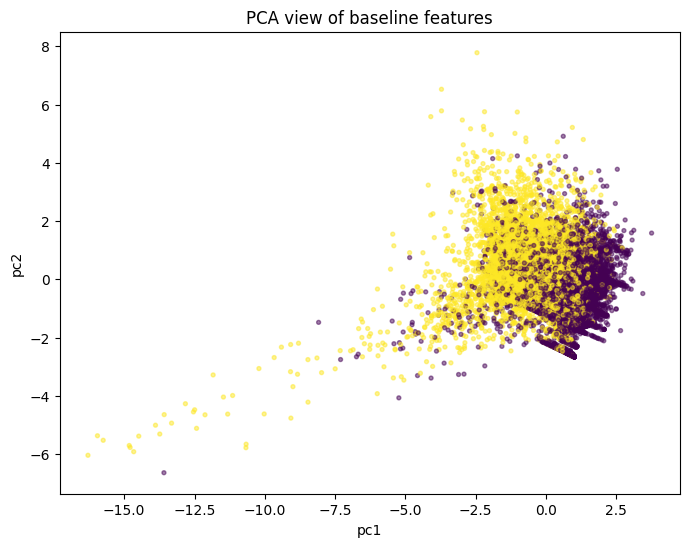

explained variance: [0.19671318 0.13278026]


In [17]:
# PCA to see the shape of the data

X_plot = prep.fit_transform(X_train)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_plot)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, s=8, alpha=0.5)
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.title("PCA view of baseline features")
plt.show()

print("explained variance:", pca.explained_variance_ratio_)